<div style="background-color:#F3F2EE">
    <br /><br />
        <p style="text-align: center;">
            <font size="6" color='#0A1781'>
                <strong>
                    Séries Temporais para Projetos de Data Science
                </strong>
              </font>
        </p>
        <p style="text-align: center;">
            <font size="6" color='#C58A1E'>
                <strong>
                    Projeto 1 - Modelagem de Séries Temporais para<br />Prever Usuários Ativos em um<br />Web Site ao Longo do Tempo - Etapa 01
                </strong>
            </font>
        </p>
    <br />
</div>

<div style="background-color:#F3F2EE">
    <p style="text-align: right;">
      <font size="4" color='#444444'>
            Roberto SSoares - LfLngLrnng
      </font>
    </p>
    <p style="text-align: right;"><font size="2" color='#444444'>
        <a href="https://www.linkedin.com/in/roberto-dos-santos-soares/">in/roberto-dos-santos-soares</a><br /><a href="https://roberto-ssoares.github.io/meu-portfolio/">Portifólio: roberto-ssoares</a>
    </p>
    <p style="text-align: right;">
        <font size="4" color='#444444'>
            " [+] Faturamento,<br \> [-] Custo,<br \> [+] Qualidade de vida "
        </font>
        <br />
        <font size="2" color='#918e8e'>"Bruno Jardim"
        </font>
    </p>        
    <p style="text-align: right;">        
        <font size="2" color='#918e8e'>           
        </font>
    </p>
</div>

<div style="background-color:#f3f2ee">
    
<font size="5" color='#CC403E'><strong>📌 Objetivo</strong></font>

<font size="3" color='#66666'>

- Este Projeto demonstra na prática o processo de modelagem de séries temporais, começando do mais absoluto zero e caminhando passo a passo até as tarefas mais avançadas.
- **Nosso trabalho é construir um modelo capaz de prever o volume de usuários ativos em um web site ao longo do tempo.**
- Usaremos dados fictícios que representam informação real.

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#FF5733'><strong>📚 Instalando e Carregando os Pacotes</strong></font>

<font size="3" color='#66666'></font></div>

In [1]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# !pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
#!pip install -q -U watermark

<div style="background-color:#f3f2ee">
    
<font size="4" color='#FF5733'><strong>📚 Importando Bibliotecas</strong></font>

<font size="3" color='#66666'></font></div>

In [2]:
# Imports
import matplotlib as m
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

<div style="background-color:#f3f2ee">
    
<font size="4" color='#FF5733'><strong>📚 Formatação para os gráficos e tabelas</strong></font>

<font size="3" color='#66666'></font></div>

In [3]:
# Formatação para os gráficos e tabelas
plt.style.use('ggplot')
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

<div style="background-color:#f3f2ee">
    
<font size="4" color='#FF5733'><strong>📚 Formatando as labels dos gráficos</strong></font>

<font size="3" color='#66666'></font></div>

In [4]:
# Formatando os labels dos gráficos
m.rcParams['axes.labelsize'] = 12
m.rcParams['xtick.labelsize'] = 10
m.rcParams['ytick.labelsize'] = 10
m.rcParams['text.color'] = 'k'

In [5]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "robertossoares-lflnglrnng" 

Author: robertossoares-lflnglrnng



<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>🔍 O Processo de Análise de Séries Temporais</strong></font>

<font size="3" color='#66666'>

- ***A análise de séries temporais é um processo estatístico que envolve a coleta, modelagem e previsão de dados ao longo do tempo.*** 
    - Ela é usada para identificar padrões, tendências e relações temporais nos dados, permitindo fazer previsões e tomar decisões informadas. 
- O processo pode ser resumido nas seguintes etapas:
  
> **1- Coleta de Dados:** 
>    - Obtenção de dados sequenciais ao longo de um período de tempo. 
>    - Os dados podem ser coletados em intervalos regulares (diários, mensais, anuais, etc.) ou irregulares.

> **2- Visualização:**
>    - Análise gráfica das séries temporais para identificar padrões visuais, como **sazonalidade, tendências, ciclos e ruídos**.

> **3- Decomposição:**
>    - Separação dos componentes principais da série temporal, como **tendência, sazonalidade e resíduos (ou ruído)**.

> **4- Estacionariedade:**
>    - Verificação da estacionariedade dos dados, ou seja, se suas **propriedades estatísticas permanecem constantes ao longo do tempo**.
>    - Caso os dados não sejam estacionários, pode ser necessário aplicar transformações, como diferenciação ou logaritmo.

> **5- Seleção do Modelo:**
>    - Escolha de um modelo adequado para ajustar os dados, como modelos:
>        - ARIMA (Autoregressive Integrated Moving Average),
>        - SARIMA (Seasonal ARIMA),
>        - modelos de médias móveis exponenciais (EMA),
>        - modelos de estado espaço ou
>        - modelos baseados em Inteligência Artificial.

> **6- Estimativa de Parâmetros e Validação:**
>    - Ajuste do modelo escolhido aos dados e verificação de sua adequação por meio de métricas de desempenho, como:
>        - erro quadrático médio (MSE),
>        - erro absoluto médio (MAE) e
>        - coeficiente de determinação (R²).

> **7- Previsão (Forecast):** 
>    - Utilização do modelo ajustado para **realizar previsões futuras, com base nos padrões identificados na série temporal**.
 
> **8- Avaliação e Atualização:** 
>    - Monitoramento do desempenho do modelo em relação às novas observações e ajuste dos parâmetros, se necessário, para melhorar as previsões futuras.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="5" color='#CC403E'><strong>⚙️ 1. Carregando e Explorando os Dados</strong></font>

<font size="3" color='#66666'></font></div>

In [8]:
# Carregando os dados
dados = pd.read_csv('../data/raw/dataset.csv', header = None)

In [9]:
# Visualizando os Dados
dados.head()

,0,1
0,2013-01,110
1,2013-02,121
2,2013-03,135
3,2013-04,127
4,2013-05,128


<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- Perceba que são duas colunas.
    - Esses dados representam **uma série univariada**, pois temos uma variável aleatória (usuarios_ativos) e a data, que representa o índice da série.
    - Veja que a série é mensal. "2013-02,2013-03,..."
- *Vamos ajustar o nome de cada coluna.*

---    
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Ajustando o nome de cada coluna:</strong></font>

<font size="3" color='#66666'></font></div>

In [10]:
# Ajustando o nome de cada coluna
dados.columns = ['mes', 'usuarios_ativos']

In [11]:
# Visualizando os Dados
dados.head()

,mes,usuarios_ativos
0,2013-01,110
1,2013-02,121
2,2013-03,135
3,2013-04,127
4,2013-05,128


In [12]:
# Shape dos Dados
print(f'Dataset com {dados.shape[0]} "observações/registros" e {dados.shape[1]} "atributos/variáveis"')

Dataset com 144 "observações/registros" e 2 "atributos/variáveis"


In [13]:
# Tipos dos Dados
dados.dtypes

mes                object
usuarios_ativos     int64
dtype: object

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- A coluna de **data está como tipo object**, que é a representação de string.
- Teremos que ajustar isso.

---
</font></div>

In [14]:
# Tipo do objeto
type(dados)

pandas.core.frame.DataFrame

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Resumo estatístico da variável usuarios_ativos:</strong></font>

<font size="2" color='#66666'></font></div>

In [16]:
# Resumo estatístico da variável usuarios_ativos. A média é de 280.
dados.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
usuarios_ativos,144.0,280.416667,119.825543,104.0,180.0,265.5,360.5,622.0


<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- A média é de 280, e a mediana 265.
    - Isso nos indica que os dados não seguem uma distribuição normal, teremos que trabalhar nisso.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Qual será o mês com o maior número de usuários ativos?</strong></font>

<font size="2" color='#66666'></font></div>

In [17]:
# Qual será o mês com o maior número de usuários ativos?
dados.max()

mes                2024-12
usuarios_ativos        622
dtype: object

In [18]:
# Vamos coletar o período completo da série temporal
print(f'Início do Período de Tempo: {dados.mes.min()}\nFinal do Período de Tempo: {dados.mes.max()}')

Início do Período de Tempo: 2013-01
Final do Período de Tempo: 2024-12


<div style="background-color:#f3f2ee">
    
<font size="5" color='#CC403E'><strong>⚙️ 2. Processamento e Visualização dos Dados</strong></font>

<font size="3" color='#66666'></font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- Vamos converter a data do tipo object (string) para o tipo apropriado, datetime, pois assim podemos usar métodos e atributos específicos de datas.
- **A ordem cronologia é muito importante, ela é parte da informação.**

---
</font></div>

In [19]:
# Visualizando os Dados
dados.head()

,mes,usuarios_ativos
0,2013-01,110
1,2013-02,121
2,2013-03,135
3,2013-04,127
4,2013-05,128


In [20]:
# Tipos dos Dados
dados.dtypes

mes                object
usuarios_ativos     int64
dtype: object

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Convertendo a coluna data de object para datetime:</strong></font>

<font size="2" color='#66666'></font></div>

In [21]:
# Convertendo a coluna data de object para datetime  
dados['mes'] = pd.to_datetime(dados['mes'], format = '%Y-%m')

In [22]:
# Tipos dos Dados
dados.dtypes

mes                datetime64[ns]
usuarios_ativos             int64
dtype: object

In [23]:
# Visualizando os Dados
dados.head()

,mes,usuarios_ativos
0,2013-01-01,110
1,2013-02-01,121
2,2013-03-01,135
3,2013-04-01,127
4,2013-05-01,128


<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Vamos transformar a coluna de data no índice do conjunto de dados:</strong></font>

<font size="2" color='#66666'></font></div>

In [24]:
# Vamos transformar a coluna de data no índice do conjunto de dados. 
# Isso vai facilitar nosso trabalho mais a frente.
dados_serie = dados.set_index('mes')

In [25]:
# Visualizando os Dados
dados_serie.head()

,usuarios_ativos
mes,
2013-01-01,110
2013-02-01,121
2013-03-01,135
2013-04-01,127
2013-05-01,128


<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- **Vamos converter a data do tipo object (string) para o tipo apropriado, datetime, pois assim podemos usar métodos e atributos específicos de datas.**  
- **Agora sim podemos chamar esse conjunto de dados de série temporal.** Vamos visualizar o índice.
- Isso vai facilitar nosso trabalho mais a frente.

---    
</font></div>

In [26]:
# Visualizando o índice
dados_serie.index

DatetimeIndex(['2013-01-01', '2013-02-01', '2013-03-01', '2013-04-01', '2013-05-01', '2013-06-01', '2013-07-01', '2013-08-01', '2013-09-01', '2013-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'], dtype='datetime64[ns]', name='mes', length=144, freq=None)

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Será que algum valor nulo está presente nos dados?</strong></font>

<font size="2" color='#66666'></font></div>

In [27]:
# Será que algum valor nulo está presente nos dados?
dados_serie.isnull().sum()

usuarios_ativos    0
dtype: int64

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>⚙️ 2.1. Plot da Série Temporal - Primeira Análise de Tendência</strong></font>

<font size="3" color='#66666'></font></div>

In [28]:
type(dados_serie)

pandas.core.frame.DataFrame

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Plot da Série Temporal - aqui já observamos algumas tendências</strong></font>

<font size="2" color='#66666'></font></div>

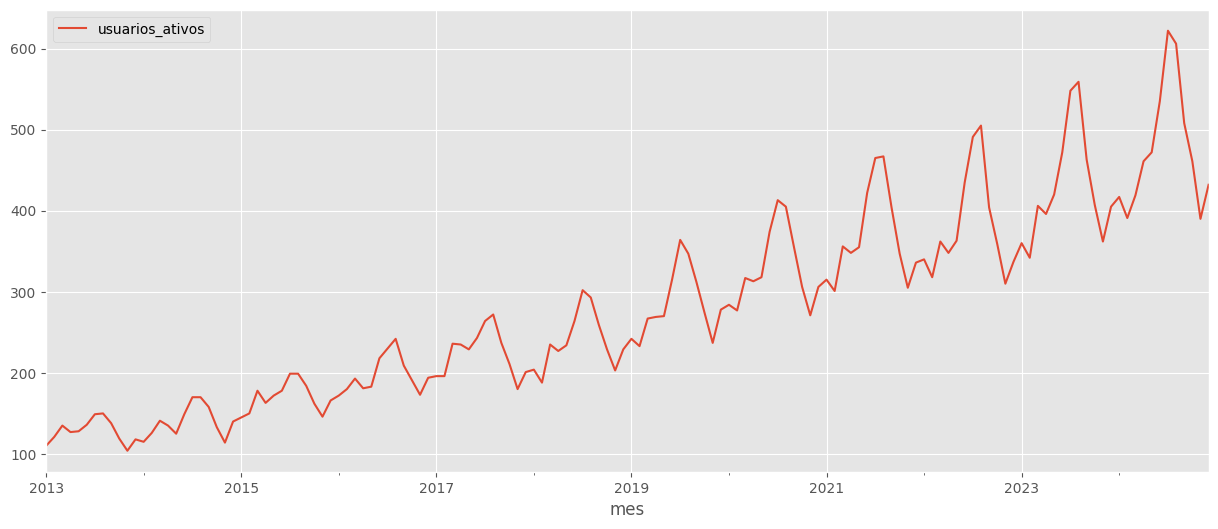

In [31]:
# Plot da Série Temporal - aqui já observamos algumas tendências
dados_serie.plot(figsize = (15, 6))
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

> - O gráfico acima mostra **2 componentes da série**: 
>    - **Sazonalidade:** O fenômeno se repete em períodos fixos.
>    - **Tendência:** Ao longo do tempo, a série segue uma tendência de crescimento.

> - Outro aspecto a considerar é o **comportamento cíclico**.
>    - Isso acontece quando o padrão de subida e descida da série não ocorre em intervalos fixos baseados em calendário.
>    - Deve-se tomar cuidado para **não confundir** efeito **"cíclico" com** efeito **"sazonal"**.
>    - Mas, como diferenciar um padrão "cíclico" versus "sazonal"?
>        - *Se os padrões não tiverem frequências fixas baseadas em calendário, será cíclico.*
>            - Porque, diferentemente da sazonalidade, ***os efeitos cíclicos são tipicamente influenciados pelos negócios e outros fatores socioeconômicos.***    

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>⚙️ 2.2. Gráfico de Densidade - Segunda Análise de Tendência</strong></font>

<font size="3" color='#66666'></font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- Analisar o gráfico da densidade de observações pode fornecer mais informações sobre a estrutura dos dados.
    - Vamos criar o gráfico:

---
</font></div>

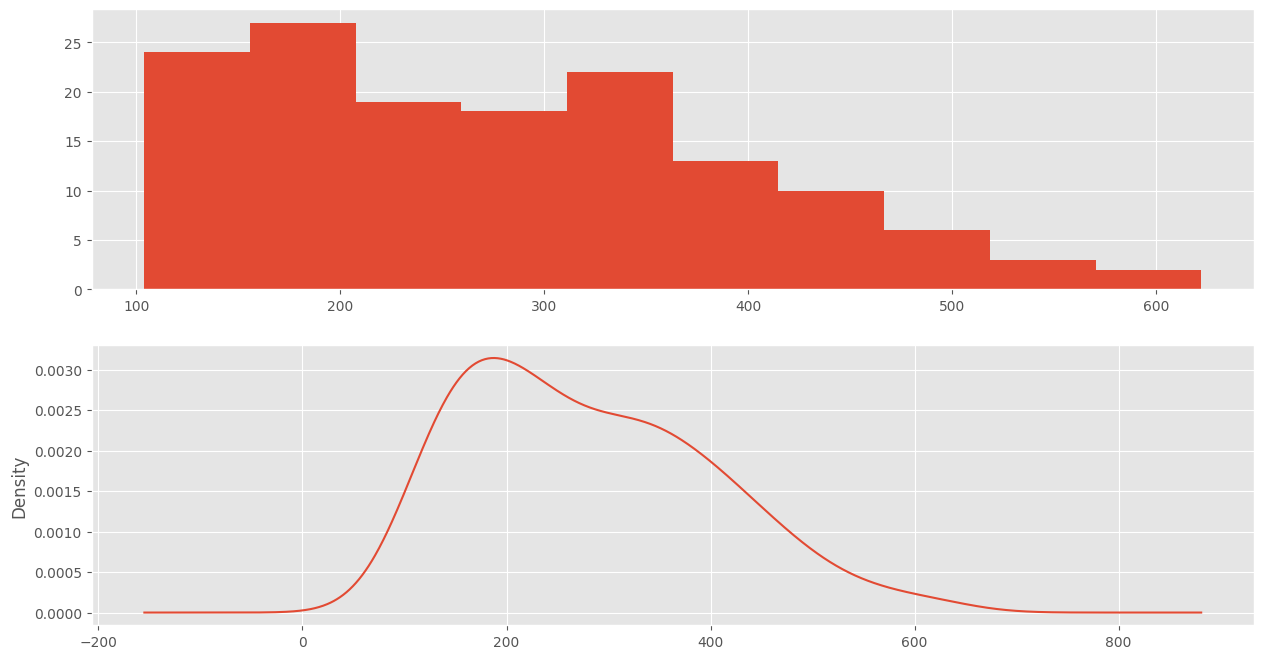

In [32]:
# Gráfico de Densidade

# Plot
plt.figure(figsize = (15, 8))

# Subplot 1
plt.subplot(211)
dados_serie.usuarios_ativos.hist()

# Subplot 2
plt.subplot(212)
dados_serie.usuarios_ativos.plot(kind = 'kde')
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- Análise: 
    - A distribuição **não é perfeitamente gaussiana (distribuição normal).**
    - A distribuição está inclinada para a esquerda.
    - ***As transformações podem ser úteis antes da modelagem.***

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>⚙️ 2.3. BoxPlots - Terceira Análise de Tendência</strong></font>

<font size="3" color='#66666'></font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- Vamos agora criar BoxPlots para cada ano da série.
- Observe que estamos extraindo o ano (year) do índice da série.

---
</font></div>

Text(0, 0.5, '\nUsuários Ativos')

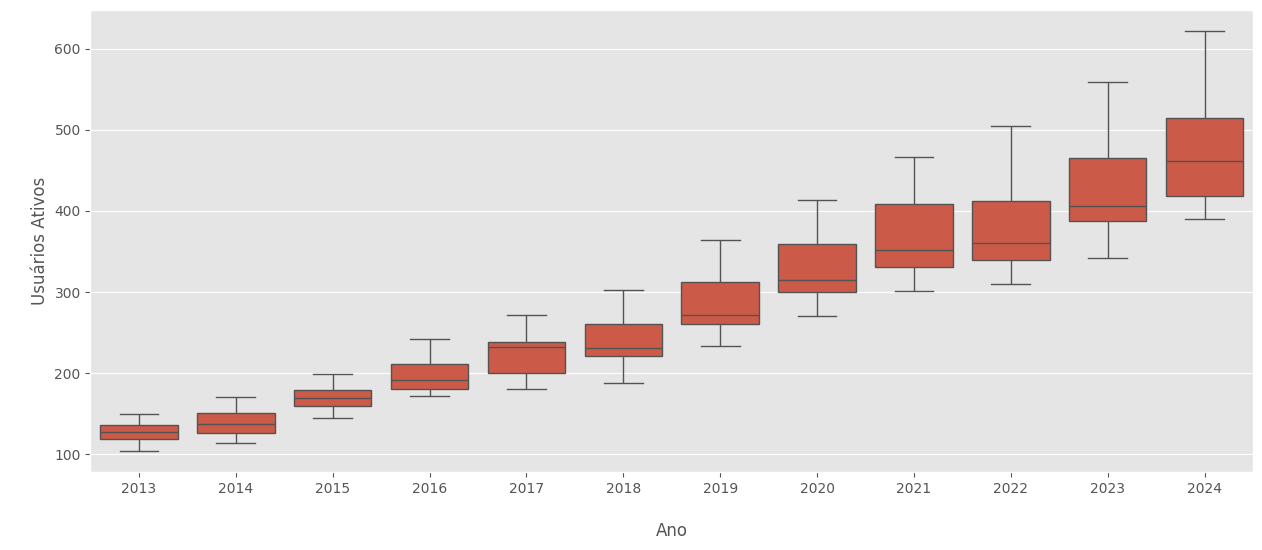

In [33]:
# Define a área de plotagem para os subplots (os boxplots)
fig, ax = plt.subplots(figsize = (15,6))

# Define as variáveis
indice_ano = dados_serie.usuarios_ativos.index.year
valor = dados_serie.usuarios_ativos

# Cria um box plot para cada ano usando o Seaborn
# Observe que estamos extraindo o ano (year) do índice da série
sns.boxplot(x = indice_ano, y = valor, ax = ax, data = dados_serie)

plt.xlabel("\nAno")
plt.ylabel("\nUsuários Ativos")

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- Análise:
    - O aumento da mediana ao longo dos anos **confirma uma tendência ascendente.**
    - **Aumento constante da dispersão ao redor da mediana** dos dados ao longo do tempo.
        - As caixas vão se tornando cada vez maiores.
    - Um modelo **considerando a sazonalidade** pode funcionar bem para prever esta série.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="5" color='#CC403E'><strong>⚙️ 3. Visualizando a Decomposição da Série Temporal</strong></font>

<font size="3" color='#66666'></font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- Vamos então decompor nossa série temporal.
    - Decomposição Multiplicativa
    - Decomposição Aditiva

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Decomposição Multiplicativa</strong></font>

<font size="2" color='#66666'></font></div>

In [35]:
# Decomposição Multiplicativa
decomposicao_multiplicativa = sm.tsa.seasonal_decompose(dados_serie, 
                                                        model = 'multiplicative', 
                                                        extrapolate_trend = 'freq')

In [36]:
# Tipo do objeto
type(decomposicao_multiplicativa)

statsmodels.tsa.seasonal.DecomposeResult

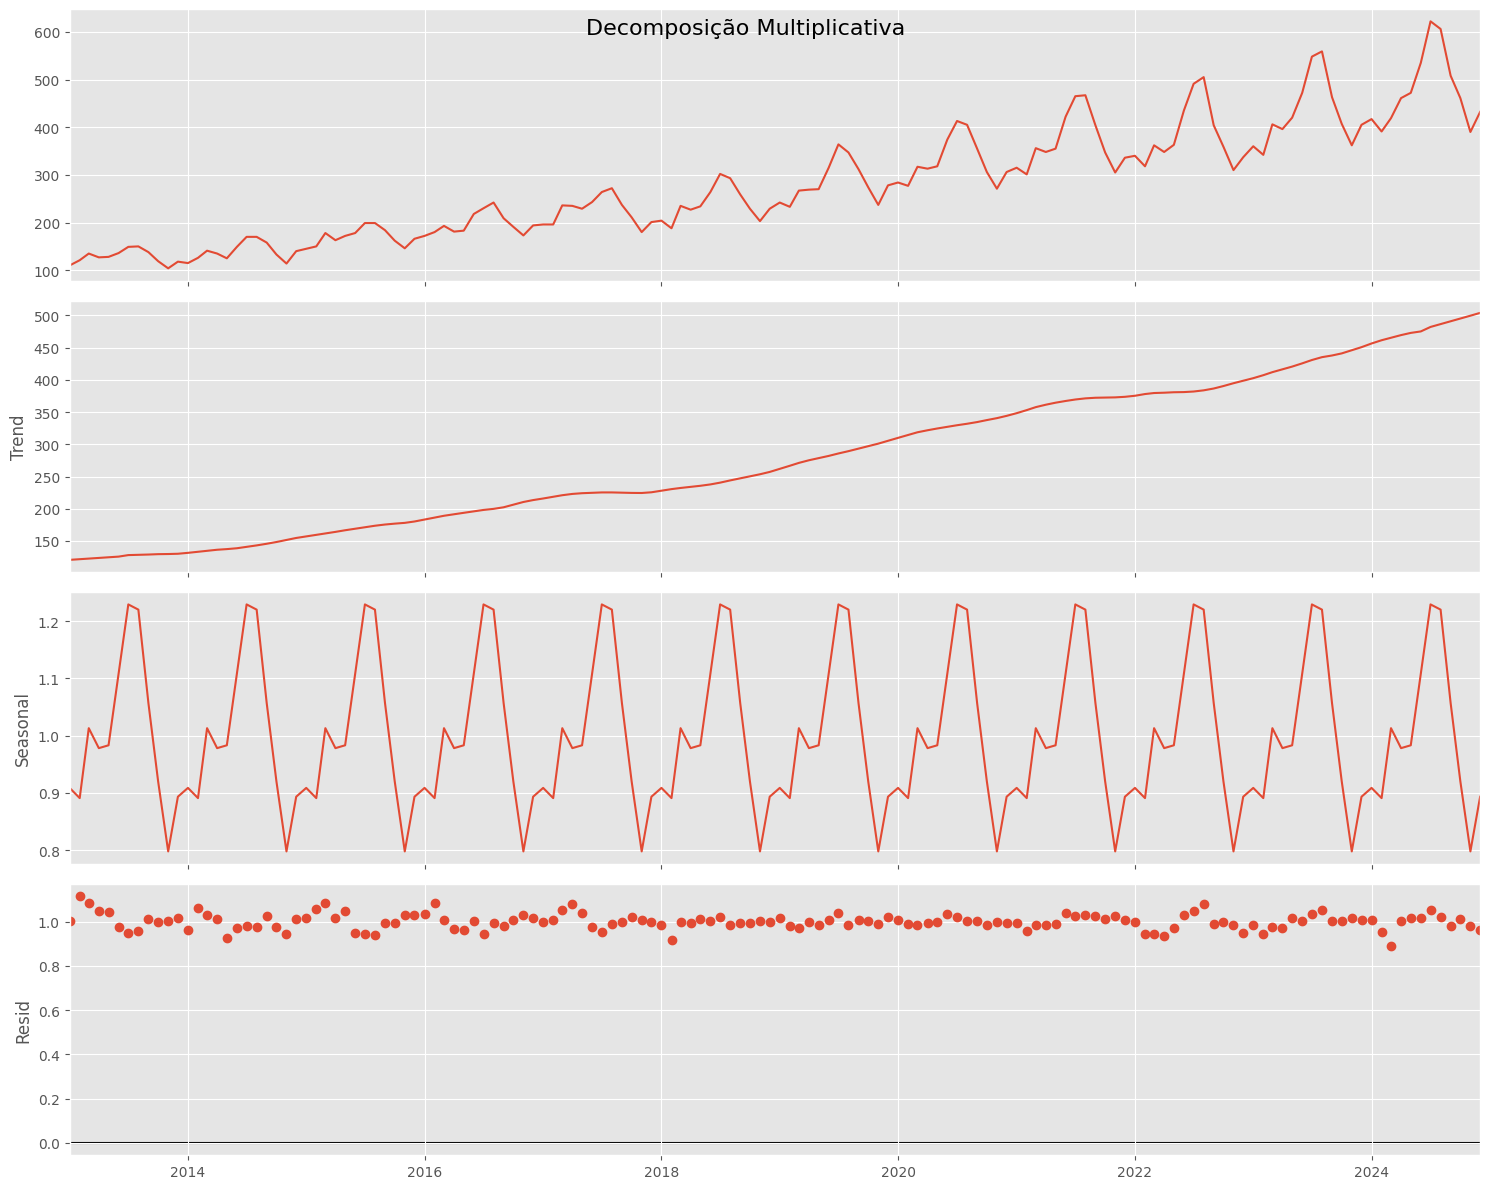

In [37]:
# Plot
plt.rcParams.update({'figure.figsize': (15,12)})
decomposicao_multiplicativa.plot().suptitle('Decomposição Multiplicativa', fontsize = 16)
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Decomposição Aditiva</strong></font>

<font size="2" color='#66666'></font></div>

In [38]:
# Decomposição Aditiva
decomposicao_aditiva = sm.tsa.seasonal_decompose(dados_serie, 
                                                 model = 'aditive', 
                                                 extrapolate_trend = 'freq')

In [39]:
# Tipo do objeto
type(decomposicao_aditiva)

statsmodels.tsa.seasonal.DecomposeResult

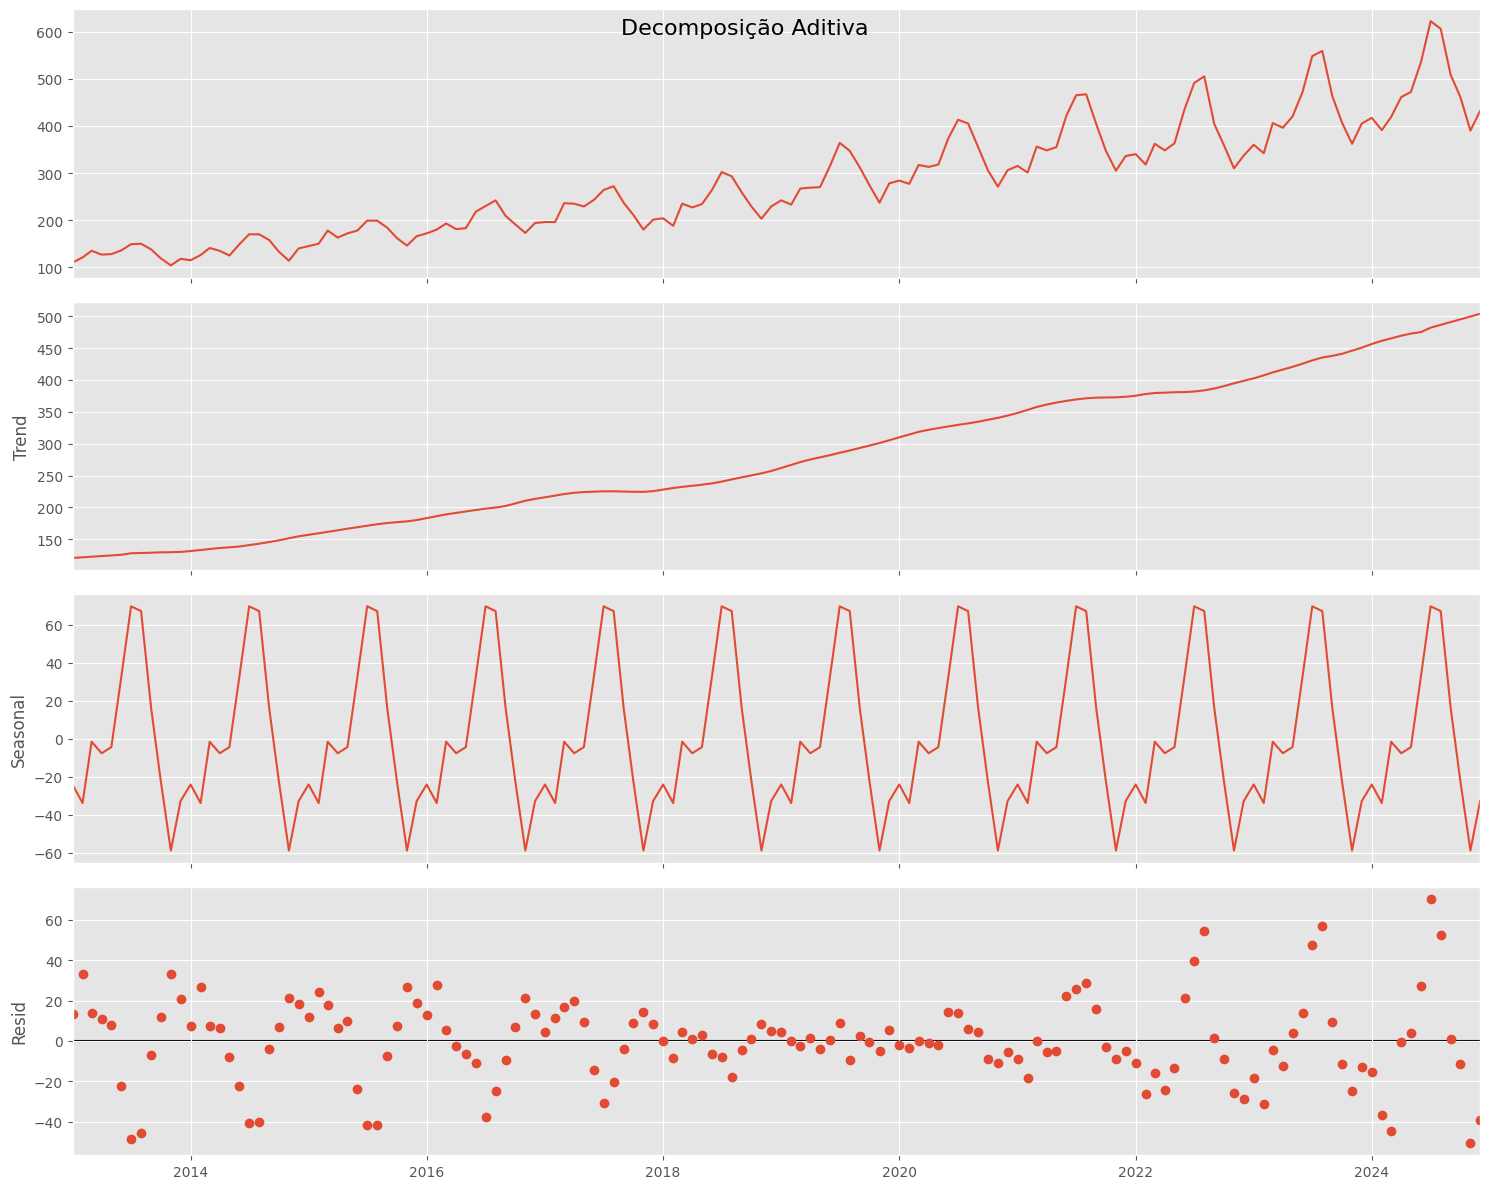

In [40]:
# Plot
plt.rcParams.update({'figure.figsize': (15,12)})
decomposicao_aditiva.plot().suptitle('Decomposição Aditiva', fontsize = 16)
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- **Análise da Decomposição da Série:**

>- No gráfico acima podemos ver os componentes da série temporal:
>    - 1. A primeira linha do gráfico mostra os dados observados, em nosso exemplo o número de usuários ativos.
>    - 2. A segunda linha mostra a tendência da série, que claramente é uma tendência de crescimento, ou seja, o número de usuários ativos tende a crescer ao longo do tempo.
>    - 3. A terceira linha mostra a sazonalidade.
>          - **Claramente temos períodos regulares de aumento e queda**, momentos em que temos valores maiores ou menores do número de usuários ativos.
>          - Isso talvez possa ser **explicado por eventos baseados em calendário (verão, inverno, férias escolares, etc...)**.
>    - 4. A quarta linha é o componete irregular ou resíduo.

>- Definir **extrapolate_trend = 'freq'** remove valores NaN na tendência e nos resíduos (se existirem, claro).

>- Se você observar atentamente os resíduos da decomposição aditiva, ela permanece com algum padrão.
>    - A decomposição multiplicativa, no entanto, parece bastante aleatória, o que é bom. 

>- **Então, idealmente, a decomposição multiplicativa deve ser preferida para essa série específica.**
>- A saída numérica da tendência, os componentes sazonais e residuais são armazenados na própria saída decomposicao_multiplicativa.
>    - Vamos extraí-los e colocá-los em uma tabela de dados.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>⚙️ 3.1. Extração dos Componentes da Série Temporal</strong></font>

<font size="3" color='#66666'></font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

> Regra de extração:
> - **Valores Reais = (sazonal * tendência * resíduo)**

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Concatena o resultado da decomposição da série (Decomposição Multiplicativa)</strong></font>

<font size="2" color='#66666'></font></div>

In [41]:
# Concatena o resultado da decomposição da série
dados_serie_reconstruida = pd.concat([decomposicao_multiplicativa.seasonal, 
                                      decomposicao_multiplicativa.trend, 
                                      decomposicao_multiplicativa.resid, 
                                      decomposicao_multiplicativa.observed], axis = 1)

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀  Define o nome das colunas</strong></font>

<font size="2" color='#66666'></font></div>

In [42]:
# Define o nome das colunas
dados_serie_reconstruida.columns = ['Sazonalidade', 'Tendência', 'Resíduos', 'Valores_Observados']

In [43]:
# Mostra o resultado
dados_serie_reconstruida.head()

,Sazonalidade,Tendência,Resíduos,Valores_Observados
mes,,,,
2013-01-01,0.908801,120.743930,1.002440,110.0
2013-02-01,0.890967,121.750194,1.115460,121.0
2013-03-01,1.013081,122.756459,1.085538,135.0
2013-04-01,0.978227,123.762723,1.048997,127.0
2013-05-01,0.983212,124.768988,1.043413,128.0


In [44]:
# Dados originais
dados_serie.head()

,usuarios_ativos
mes,
2013-01-01,110
2013-02-01,121
2013-03-01,135
2013-04-01,127
2013-05-01,128


<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- Se você checar, o produto das colunas ***Sazonalidade, Tendência e Resíduos deve ser exatamente igual a Valores_Observados***.
- Por exemplo:
    - Série na data 2013-01-01 = 110.0
    - Série na data 2013-01-01 = Sazonalidade x Tendência x Resíduos = 0.908801 x 120.743930 x 1.002440 = 110.0

---
</font></div>

In [45]:
# Cálculo em Python
valor_observado = np.round(0.908801 * 120.743930 * 1.002440)
print(valor_observado)

110.0


<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- Ou seja, isso comprova como **uma série temporal é na verdade o conjunto de componentes que podem ser extraídos, transformados, analisados e usados para fazer previsões**.

> Concluímos assim a primeira etapa do Projeto.

> Vamos para a segunda etapa.

---
</font></div>

In [46]:
%reload_ext watermark
%watermark -a "robertossoares-lflnglrnng"

Author: robertossoares-lflnglrnng



In [47]:
%watermark -v -m

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.4.0

Compiler    : MSC v.1943 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 158 Stepping 9, GenuineIntel
CPU cores   : 4
Architecture: 64bit



In [48]:
%watermark --iversions

matplotlib : 3.10.3
numpy      : 2.3.1
pandas     : 2.3.1
seaborn    : 0.13.2
statsmodels: 0.14.5



<div style="background-color:#f3f2ee">
    
<font size="6" color='#CC403E'><strong>Fim</strong></font>

<font size="3" color='#66666'></font></div>

In [51]:
#!pip install nbconvert -U -q
!jupyter nbconvert p01-etapa01.ipynb --to html --template D:/_jupyter/my-template-html-v07.tpl

[NbConvertApp] Converting notebook p01-etapa01.ipynb to html
[NbConvertApp] Writing 556467 bytes to p01-etapa01.html
